In [2]:
!pip install seaborn

# Classic Metrics Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results (if not already in memory)
df = pd.read_csv("ollama_eval_results_gemma.csv")

# Drop any rows with missing or error values
df_clean = df.dropna(subset=["rougeL_f1", "bleu", "cosine", "bertscore_f1"], how="any")


In [7]:
df_clean.head()

,claim,label,justification,label_pred,justification_pred,rougeL_f1,bleu,cosine,bertscore_f1
0,35% of revenue goes to states. (In Nigeria),Refuted,The answer shows that 26.72% goes to states so...,Refuted,According to the Nigerian National Bureau of S...,0.081633,1.235039,0.284774,0.178510
1,The Common Law Admission Test (CLAT) 2020 will...,Refuted,The answer and credible source show that the c...,Refuted,The Common Law Admission Test (CLAT) 2020 was ...,0.140351,1.279087,0.087320,0.065769
2,Donald Trump delivered the largest tax cuts in...,Refuted,Three tax bills have been larger than that of ...,Refuted,While the Tax Cuts and Jobs Act of 2017 did in...,0.062500,0.718846,0.564513,-0.034126
3,"After the police shooting of Jacob Blake, Gov....",Refuted,Governor Evers did call for peace in a video s...,Refuted,Immediately following the shooting of Jacob Bl...,0.126984,0.838553,0.529204,0.255077
4,Biden will take away the Second Amendment.,Refuted,Biden does not want to end second amendment,Refuted,President Biden has repeatedly stated his supp...,0.140351,0.832775,0.686665,0.259683


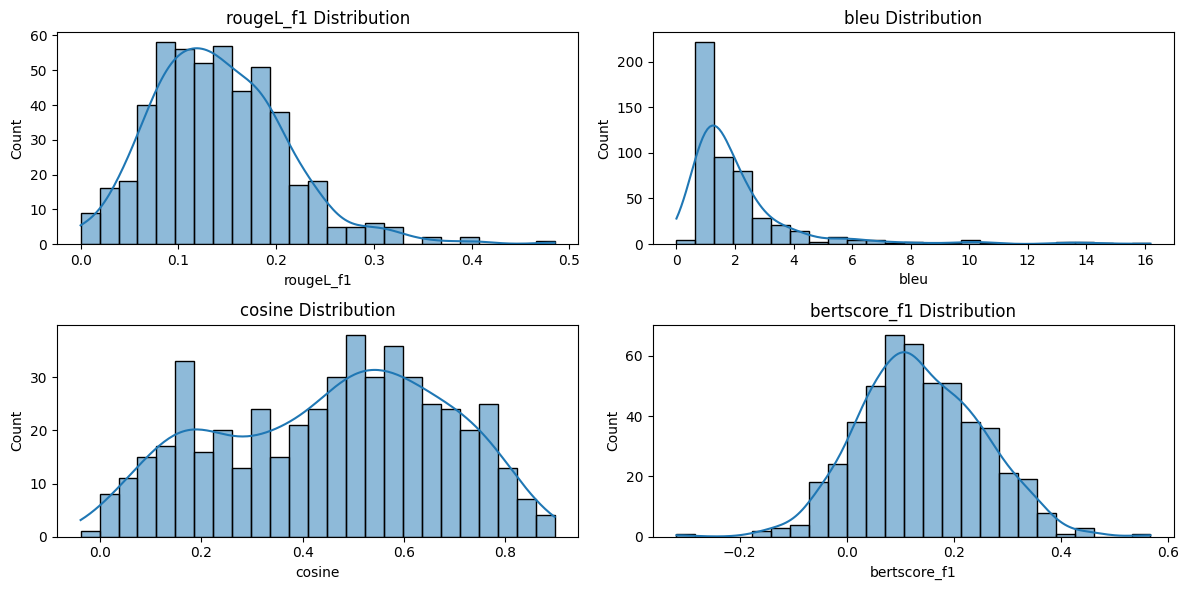

In [4]:
metrics = ["rougeL_f1", "bleu", "cosine", "bertscore_f1"]

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[metric], bins=25, kde=True)
    plt.title(f"{metric} Distribution")
    plt.xlabel(metric)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


1. ROUGE-L F1 Distribution

Shape: Right-skewed (long tail to the right)

Concentration: Most values lie between 0.05 and 0.25, with a sharp drop-off beyond 0.3.

Interpretation:

The majority of generated texts have low lexical overlap with the reference texts.

Only a few samples achieve moderate overlap (ROUGE-L > 0.3).

This may indicate diverse wording, paraphrasing, or weak surface similarity.

2. BLEU Distribution

Shape: Highly right-skewed with a long tail; a few extreme outliers (up to ~16).

Concentration: Most values are below 2–3.

Interpretation:

BLEU scores are heavily concentrated at low values, suggesting that n-gram overlap is minimal.

This could occur if your generated sentences differ syntactically or use synonyms frequently — BLEU tends to penalize such variation harshly.

The rare high BLEU values likely correspond to near-identical matches.

3. Cosine Similarity Distribution

Shape: Bimodal or multi-peaked (one cluster around 0.2, another around 0.6).

Range: 0 to 0.9, with most between 0.3–0.7.

Interpretation:

Two distinct groups of examples  one where embeddings align well with reference text (semantic match), and one where they don’t.

Possibly your dataset includes both closely and loosely related generations (e.g., factual vs. creative responses).

4. BERTScore F1 Distribution

Shape: Approximately normal (bell-shaped).

Mean: Around 0.1–0.15; symmetric spread between -0.2 and 0.5.

Interpretation:

Indicates moderate semantic similarity on average.

BERTScore is more forgiving to paraphrases, so these values being low–midrange suggest the model captures partial meaning overlap but struggles with deeper equivalence.

C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\2478274742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_scores.values, y=mean_scores.index, palette="Blues_r")


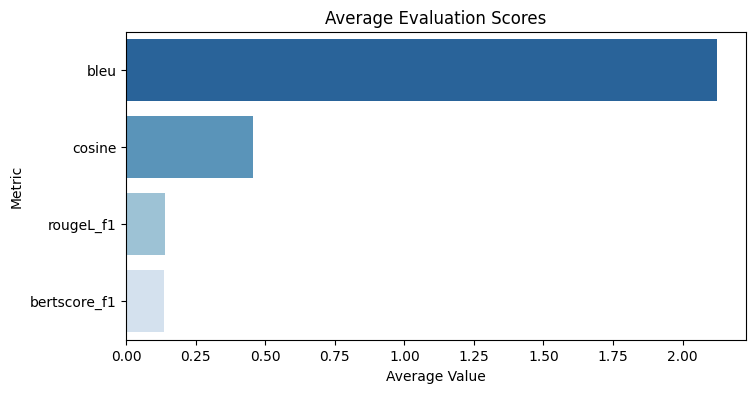

bleu            2.121707
cosine          0.456412
rougeL_f1       0.141162
bertscore_f1    0.137948
dtype: float64


In [5]:
mean_scores = df_clean[metrics].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=mean_scores.values, y=mean_scores.index, palette="Blues_r")
plt.title("Average Evaluation Scores")
plt.xlabel("Average Value")
plt.ylabel("Metric")
plt.show()

print(mean_scores)


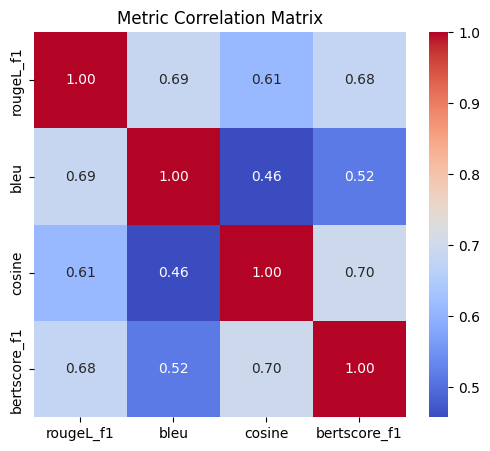

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_clean[metrics].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Metric Correlation Matrix")
plt.show()


| Metric Pair             | Correlation | Interpretation                                                                                     |
| ----------------------- | ----------- | -------------------------------------------------------------------------------------------------- |
| **ROUGE-L ↔ BLEU**      | 0.69        | Strong positive : both measure *lexical overlap*, so they increase together.                       |
| **ROUGE-L ↔ Cosine**    | 0.61        | Moderate : lexical similarity partly aligns with semantic similarity.                              |
| **ROUGE-L ↔ BERTScore** | 0.68        | Strong : BERTScore captures semantics, but overlap still influences it.                            |
| **BLEU ↔ Cosine**       | 0.46        | Weak-to-moderate : BLEU’s strict n-gram match doesn’t fully align with embedding-based similarity. |
| **BLEU ↔ BERTScore**    | 0.52        | Moderate : some shared trend, but BLEU is more brittle to paraphrasing.                            |
| **Cosine ↔ BERTScore**  | 0.70        | Strong : both are *semantic metrics*, so they track closely.                                       |


## Two clusters emerge:

Lexical metrics: (ROUGE-L, BLEU ) rely on word-level overlap.

Semantic metrics: ( Cosine, BERTScore ) depend on meaning and embeddings.

Bridging metric:

ROUGE-L acts as a bridge between lexical and semantic similarity (moderate correlations with both groups).

BLEU is the most distinct metric:

Its lower correlation (especially 0.46 with cosine) suggests it’s more sensitive to surface-level phrasing, and less to meaning.

Cosine and BERTScore are conceptually and statistically aligned:

With a 0.70 correlation, they reinforce each other’s semantic evaluation , suggesting your model’s meaning-preserving capability is somewhat consistent across these two measures.

## Interpretation Summary

Models that achieve high ROUGE-L likely produce texts with good overlap and partially good semantics.

High BLEU doesn’t always imply strong semantic alignment , it’s possible to get a high BLEU but poor cosine/BERTScore.

Cosine and BERTScore together give a more robust sense of semantic quality, while ROUGE-L shows surface similarity consistency.

In [2]:
# Model predicted Label vs Actual Label (both refuted)
"""" 
df_clean["correct_label"] = (df_clean["label"] == df_clean["label_pred"]).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="correct_label", y="bertscore_f1", palette="Set2")
plt.title("BERTScore vs Label Correctness")
plt.xlabel("Correct Label (1=True)")
plt.ylabel("BERTScore F1")
plt.show()

"""




'" \ndf_clean["correct_label"] = (df_clean["label"] == df_clean["label_pred"]).astype(int)\n\nplt.figure(figsize=(10, 6))\nsns.boxplot(data=df_clean, x="correct_label", y="bertscore_f1", palette="Set2")\nplt.title("BERTScore vs Label Correctness")\nplt.xlabel("Correct Label (1=True)")\nplt.ylabel("BERTScore F1")\nplt.show()\n\n'

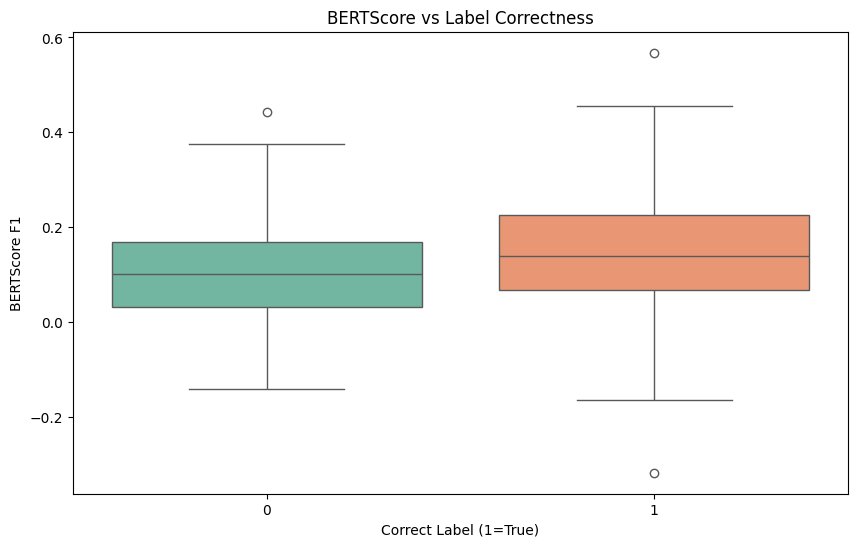

Median Shift:

Median BERTScore F1 for correct labels (1) is slightly higher than for incorrect labels (0).

This shows that, on average, correctly predicted outputs have better semantic alignment with the reference.

Distribution Spread:

Both groups have overlapping interquartile ranges (IQRs), but correct examples show a wider upper tail — some reach ~0.5+.

Incorrect ones are more concentrated around 0.0–0.15, indicating lower semantic similarity.

Outliers:

Both sides have a few outliers (e.g., high scores for wrong predictions and low scores for correct ones).

This suggests BERTScore isn’t perfectly correlated with correctness . it may reward semantically similar but factually wrong outputs.

Overall Pattern:

Despite overlap, there’s a positive trend: higher BERTScore generally aligns with correctness, but not deterministically.

Interpretation

BERTScore appears to be a useful but imperfect proxy for correctness.

It captures semantic closeness (meaning similarity), but not factual accuracy  a common limitation in text evaluation.

The overlap implies that semantic similarity doesn’t always imply truthfulness, especially if the model outputs fluent but wrong statements.



# Labels classification

In [ ]:
# Normalize labels to lowercase to avoid mismatch
df["label"] = df["label"].str.lower().str.strip()
df["label_pred"] = df["label_pred"].str.lower().str.strip()

# Filter rows where ground truth is refuted but predicted as accepted
false_pos = df[
    (df["label"] == "refuted") &
    (df["label_pred"] == "supported")
]

print(f"⚠️ Found {len(false_pos)} false positives (Refuted → supported).")
false_pos[["claim", "label", "label_pred", "justification", "justification_pred"]].head(10)


⚠️ Found 97 false positives (Refuted → Accepted).


,claim,label,label_pred,justification,justification_pred
8,We actually saw revenues to the Treasury incre...,refuted,supported,"From the evidence below, it looks like the rev...",According to the Congressional Budget Office (...
15,South African consume more alcohol per person ...,refuted,supported,It seems that SA consumes less alcohol. Theref...,According to multiple studies and reports from...
24,Candace Owens was fired from her show at One A...,refuted,supported,It seems that the website is for satire and is...,Multiple news sources reported that Candace Ow...
27,Mughal Gardens Renamed To Dr. Rajendra Prasad ...,refuted,supported,"On the official Mughal gardens website, it is ...",The Mughal Gardens of Badshahi Fort were offic...
28,Trumps January 2018 travel ban was unlawful.,refuted,supported,Q&A 2 states the actuall law that made it lega...,A federal judge blocked President Trump's revi...
50,The media is ignoring the tragic death of a 5-...,refuted,supported,The tragic death of the 5-year-old boy was ade...,"Numerous news outlets, including The New York ..."
51,"The murder of Oscar Grant, by a police officer...",refuted,supported,The second source shows that the officer was c...,Officer William James was initially charged wi...
52,Former president Pranab Mukherjee from India h...,refuted,supported,Evidence does not show that he had died at the...,"Pranab Mukherjee, the 14th President of India,..."
56,"Kamala Harris said ""And once Trump’s gone and ...",refuted,supported,The claim comes from a satire website called b...,"During a private fundraiser in September 2023,..."
58,"Kamala Harris was descended from enslavers, an...",refuted,supported,It seems from the 3rd QA that she openly admit...,Research by the Los Angeles Times revealed tha...


In [19]:
print("Ground truth labels:", df["label"].unique())
print("Predicted labels:", df["label_pred"].unique())


Ground truth labels: ['refuted']
Predicted labels: ['refuted' 'supported']


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Binary representation: 1 = refuted (true), 0 = not refuted (wrongly supported)
y_true = (df["label"] == "refuted").astype(int)
y_pred = (df["label_pred"] == "refuted").astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],
    "Score": [precision, recall, f1]
})

metrics_df


,Metric,Score
0,Precision,1.00000
1,Recall,0.80600
2,F1-score,0.89258


C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\3716756949.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


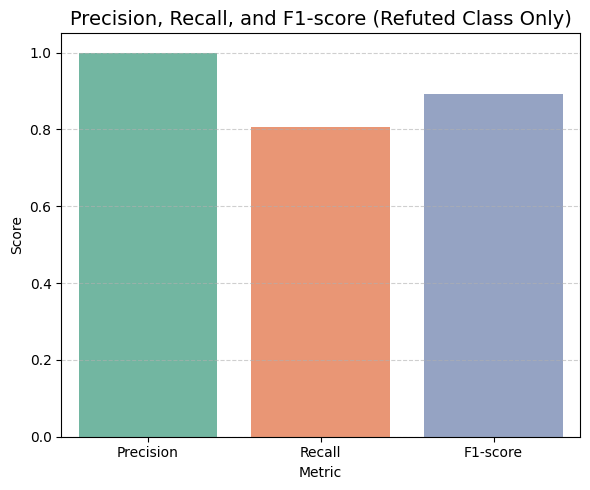

In [21]:
plt.figure(figsize=(6, 5))
sns.barplot(
    data=metrics_df,
    x="Metric",
    y="Score",
    palette="Set2"
)

plt.title("Precision, Recall, and F1-score (Refuted Class Only)", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Check if classification correctness correlates with justification quality

In [22]:
# Add a binary column for correctness
df["is_correct"] = (df["label"] == df["label_pred"]).astype(int)

print(df["is_correct"].value_counts())


is_correct
1    403
0     97
Name: count, dtype: int64


C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\920156785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_correct", y=metric, palette="Set2")
C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\920156785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_correct", y=metric, palette="Set2")
C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\920156785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_correct", y=metric, palette="Set2")
C:\Users\edupa\AppData\Local\Temp\ipykernel_24780\92015678

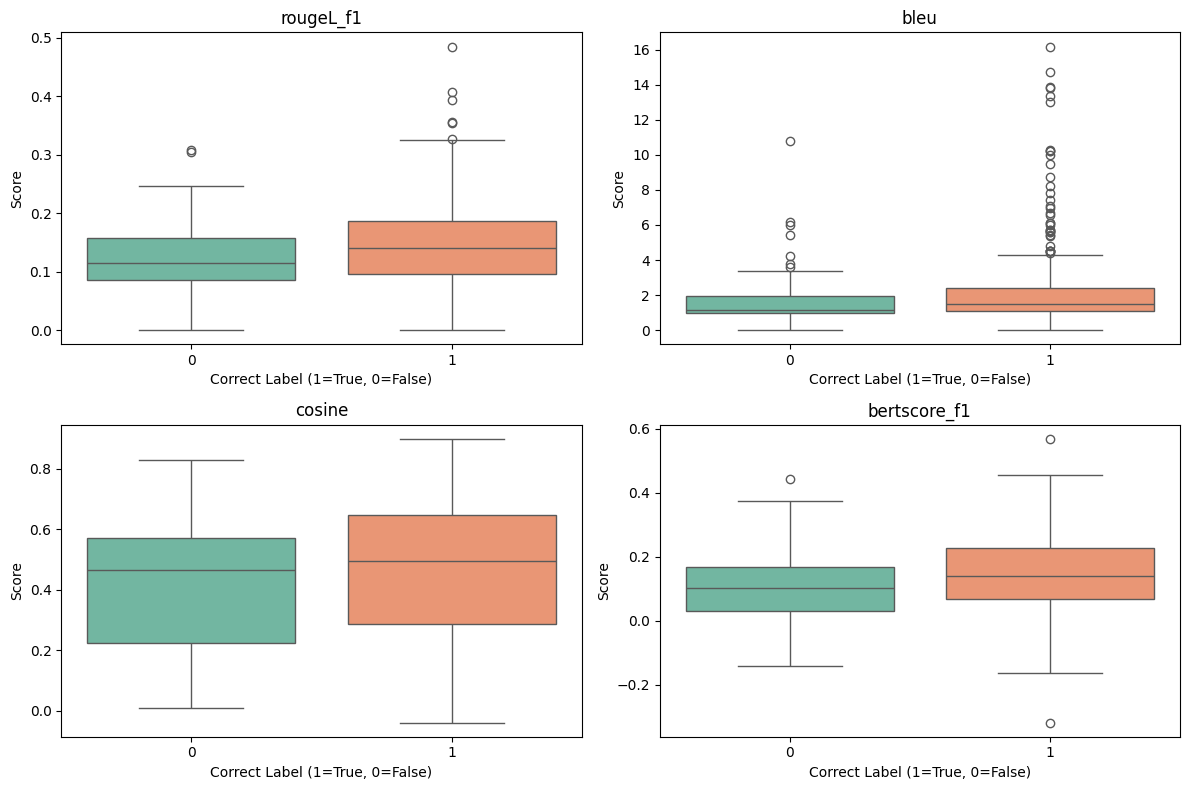

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ["rougeL_f1", "bleu", "cosine", "bertscore_f1"]

plt.figure(figsize=(12, 8))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="is_correct", y=metric, palette="Set2")
    plt.title(metric)
    plt.xlabel("Correct Label (1=True, 0=False)")
    plt.ylabel("Score")

plt.tight_layout()
plt.show()


 1. ROUGE-L F1

Observation: Median for correct labels (1) is slightly higher (~0.13–0.15) than for incorrect (~0.1).

Spread: Narrow distribution for both, with more outliers on the correct side.

Interpretation:

Correct predictions tend to have somewhat higher lexical overlap.

However, the difference is small → ROUGE-L is only a weak discriminator of correctness.

 2. BLEU

Observation: Slight increase in median for correct labels; however, massive variance and outliers dominate.

Interpretation:

BLEU is unstable — many correct examples have low BLEU, while some incorrect ones have extremely high BLEU (outliers beyond 10–15).

This reinforces that BLEU is not reliable for short or paraphrased responses, as it’s sensitive to exact n-gram matches.

 3. Cosine Similarity

Observation: Distributions overlap considerably, but correct examples show slightly higher upper quartiles and a broader range.

Interpretation:

Semantic similarity (cosine) improves for correct cases, but not strongly enough to clearly separate the two classes.

Some incorrect responses still have high cosine similarity — likely semantically close but factually wrong.

 4. BERTScore F1

Observation: Correct samples show a clear upward shift in median and upper quartile.

Spread: Reasonably compact, fewer extreme outliers.

Interpretation:

BERTScore is the most discriminative among the four.

It captures semantic correctness better, aligning more consistently with the label truth.


## Summary

BERTScore is the most reliable metric for distinguishing correct vs. incorrect outputs.

BLEU performs poorly and should not be used alone.

ROUGE-L provides some signal but lacks discriminative strength.

Cosine provides useful complementary semantic insight.

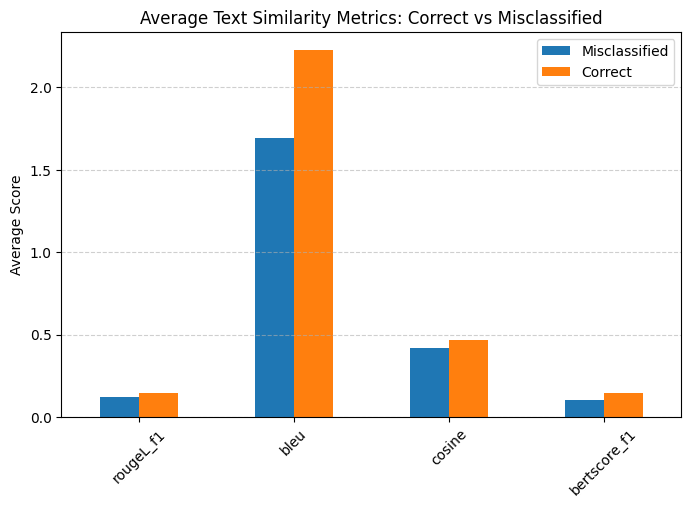

,Misclassified,Correct
rougeL_f1,0.123995,0.145295
bleu,1.694053,2.224641
cosine,0.421076,0.464917
bertscore_f1,0.103220,0.146307


In [24]:
group_means = df.groupby("is_correct")[metrics].mean().T
group_means.columns = ["Misclassified", "Correct"]
group_means.plot.bar(figsize=(8, 5))
plt.title("Average Text Similarity Metrics: Correct vs Misclassified")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

group_means


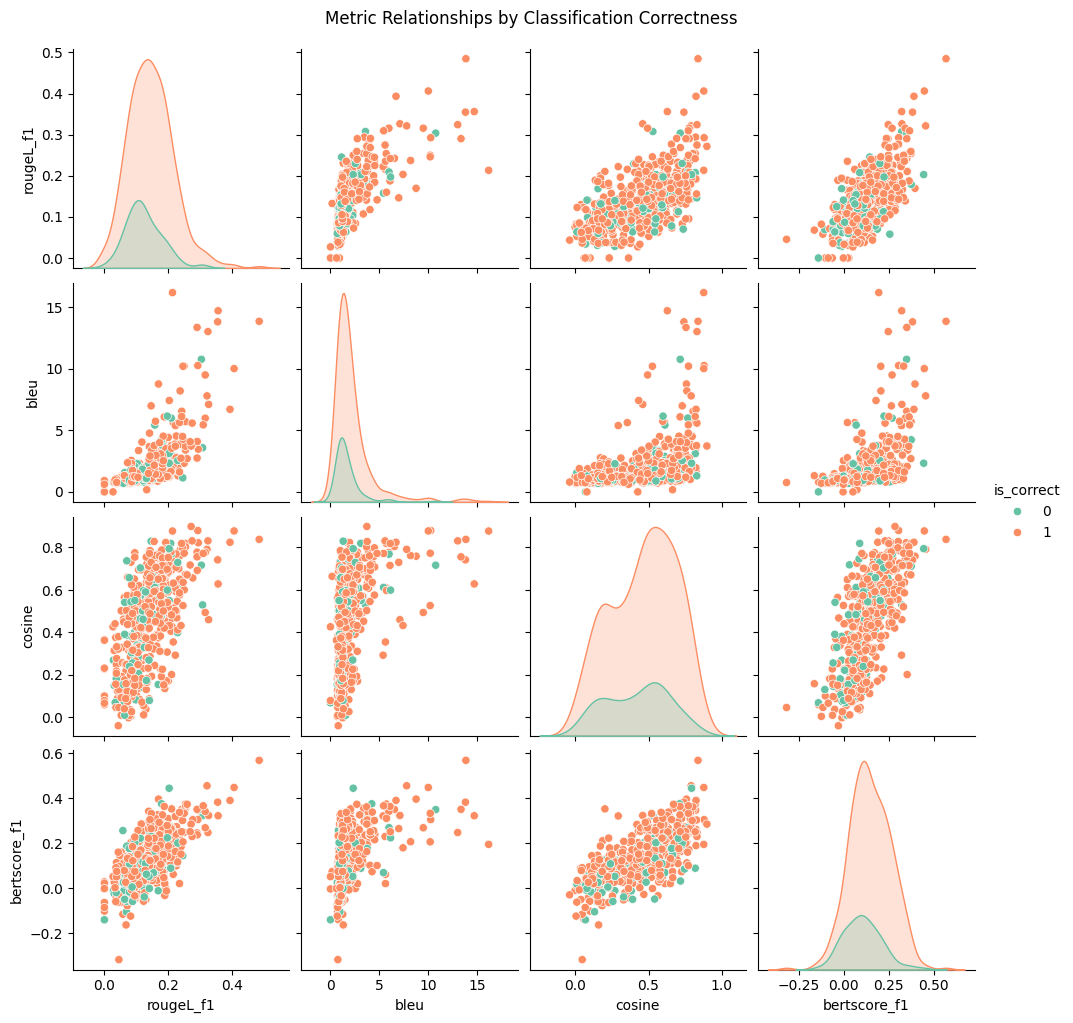

In [27]:
sns.pairplot(df, vars=metrics, hue="is_correct", palette="Set2", diag_kind="kde")
plt.suptitle("Metric Relationships by Classification Correctness", y=1.02)
plt.show()
